In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [12]:
def prepare_data(x):
    #med_filtered_frame = scipy.signal.medfilt(x, kernel_size=3)
    x_normalized = x / 255.0 if x.max() > 1.0 else x

    # 2. Apply threshold (0.5) and cast to integer
    x_binarized = (x_normalized > 0.5).astype(np.float32)
    return x_normalized

# Load the archive
test_data = np.load('arrows8_keras_format.npz')

# List the keys to see what's inside
print("Keys in file:", test_data.files)

# Extract images and labels (replace 'x_test'/'y_test' with your actual keys)
x_train = test_data['x_train']
y_train = test_data['y_train']

x_val = test_data['x_val']
y_val = test_data['y_val']

x_test = test_data['x_test']
y_test = test_data['y_test']

x_train = prepare_data(x_train)
x_val = prepare_data(x_val)
x_test = prepare_data(x_test)

print(f"Test data shape: {x_test.shape}")



Keys in file: ['x_train', 'y_train', 'x_val', 'y_val', 'x_test', 'y_test', 'class_names']
Test data shape: (4078, 8, 8, 1)


In [13]:
def display_pred_grid(x_test, y_test, predicted_labels):
    # 'facecolor' sets the background color of the whole window
    fig = plt.figure(figsize=(10, 6)) 
    
    for i in range(15):
        # Set the background for each individual subplot
        ax = plt.subplot(3, 5, i + 1)
        
        img = np.squeeze(x_test[i])
        true_label = y_test.flatten()[i]
        named_label = ["up", "left", "down", "right"][true_label]
        predicted_label = predicted_labels[i]
        named_predicted_label = ["up", "left", "down", "right"][predicted_label]
        
        # Display image
        plt.imshow(img, cmap='viridis', interpolation='nearest')
        
        # Change text color to white so it's visible on the gray background
        plt.title(f"True: {named_label}\nPredicted: {named_predicted_label}", fontsize=9)
        plt.axis('off')
    
    plt.subplots_adjust(wspace=0.1, hspace=0.4)
    plt.show()

## hls4ml conversion for hardware

These cells generate the working fixed-point HLS network directly from the trained notebook model. The default hardware model removes the final softmax and outputs four logits; use `argmax` on those logits to pick the arrow class.


In [14]:
import shutil
from pathlib import Path

import hls4ml
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

saved_model_path = Path('wedrowiec-pre_hls.h5')
hls_project_name = 'wedrowiec_hls'
hls_output_dir = Path('hls4ml_projects') / hls_project_name
clean_hls_output = True

# 'logits' removes final softmax from HLS and outputs four fixed-point scores.
# Classify with np.argmax(scores, axis=1).
# 'one_hot' keeps a softmax-shaped output but implements it as hardware argmax.
hls_output_mode = 'logits'

try:
    keras_reference_model = model
except NameError:
    keras_reference_model = tf.keras.models.load_model(saved_model_path, compile=False)

def clone_without_final_softmax(keras_model):
    hls_ready_model = models.Sequential(name=f'{keras_model.name}_logits')
    hls_ready_model.add(layers.Input(shape=keras_model.input_shape[1:], name='input_layer'))

    copied_layers = []
    for layer in keras_model.layers:
        if isinstance(layer, layers.InputLayer):
            continue

        config = layer.get_config()
        if isinstance(layer, layers.Dense) and config.get('activation') == 'softmax':
            config['activation'] = 'linear'

        new_layer = layer.__class__.from_config(config)
        hls_ready_model.add(new_layer)
        copied_layers.append((layer, new_layer))

    for old_layer, new_layer in copied_layers:
        weights = old_layer.get_weights()
        if weights:
            new_layer.set_weights(weights)

    return hls_ready_model

if hls_output_mode == 'logits':
    keras_model_for_hls = clone_without_final_softmax(keras_reference_model)
    final_activation = getattr(keras_model_for_hls.layers[-1].activation, '__name__', '')
    if final_activation != 'linear':
        raise RuntimeError(f'Expected linear final HLS layer, got {final_activation}')
elif hls_output_mode == 'one_hot':
    keras_model_for_hls = keras_reference_model
else:
    raise ValueError("hls_output_mode must be 'logits' or 'one_hot'")

def match_model_input_shape(x, keras_model):
    x = np.asarray(x, dtype=np.float32)
    input_shape = tuple(keras_model.input_shape[1:])

    if any(dim is None for dim in input_shape):
        raise ValueError(f'Model input shape is not fully defined: {keras_model.input_shape}')

    if x.shape[1:] == input_shape:
        matched = x
    elif x.ndim == 4 and x.shape[-1] == 1 and x.shape[1:-1] == input_shape:
        matched = np.squeeze(x, axis=-1)
    elif len(input_shape) == 3 and input_shape[-1] == 1 and x.ndim == 3 and x.shape[1:] == input_shape[:-1]:
        matched = x[..., np.newaxis]
    else:
        matched = x.reshape((x.shape[0], *input_shape))

    matched = np.ascontiguousarray(matched, dtype=np.float32)
    print(f'Keras/HLS input shape: {matched.shape}, dtype: {matched.dtype}')
    return matched

print(f'HLS output mode: {hls_output_mode}')
print(f'HLS model final activation: {getattr(keras_model_for_hls.layers[-1].activation, "__name__", "n/a")}')


HLS output mode: logits
HLS model final activation: linear


### Conversion configuration

In [15]:
hls_backend = 'Vitis'
board_name = 'PYNQ-Z2'
fpga_part = 'xc7z020clg400-1'
clock_period = 20 # 50 MHz is a relaxed starting point for PYNQ-Z2 timing closure.
hls_precision = 'fixed<6,4,RND,SAT>'
#hls_precision = 'int<8>'
#hls_input_precision = 'ufixed<8,1,RND,SAT>'
hls_input_precision = 'int<8>'
io_type='io_stream'
hls_reuse_factor = 2048

hls_config = hls4ml.utils.config_from_keras_model(
    keras_model_for_hls,
    granularity='name',
    backend=hls_backend,
    default_precision=hls_precision,
    default_reuse_factor=hls_reuse_factor,
)

hls_config['Model']['Strategy'] = 'Resource'
hls_config['LayerName']['input_layer']['Precision']['result'] = hls_input_precision

if hls_output_mode == 'logits' and 'dense_3_softmax' in hls_config['LayerName']:
    raise RuntimeError('Stale HLS model: dense_3_softmax is present. Rerun the HLS setup cell first.')

if hls_output_mode == 'one_hot' and 'dense_3_softmax' in hls_config['LayerName']:
    hls_config['LayerName']['dense_3_softmax']['Implementation'] = 'argmax'

hls_config


{'Model': {'Precision': {'default': 'fixed<6,4,RND,SAT>'},
  'ReuseFactor': 2048,
  'Strategy': 'Latency',
  'BramFactor': 1000000000,
  'TraceOutput': False},
 'LayerName': {'input_layer': {'Trace': False,
   'Precision': {'result': 'int<8>'}},
  'flatten': {'Trace': False, 'Precision': {'result': 'auto'}},
  'dense_4': {'Trace': False,
   'Precision': {'result': 'auto',
    'weight': 'auto',
    'bias': 'auto',
    'accum': 'auto'},
   'ReuseFactor': 2048},
  'dense_4_relu': {'Trace': False,
   'Precision': {'result': 'auto', 'table': 'fixed<18,8,TRN,WRAP,0>'},
   'ReuseFactor': 2048,
   'TableSize': 1024},
  'dense_5': {'Trace': False,
   'Precision': {'result': 'auto',
    'weight': 'auto',
    'bias': 'auto',
    'accum': 'auto'},
   'ReuseFactor': 2048},
  'dense_5_relu': {'Trace': False,
   'Precision': {'result': 'auto', 'table': 'fixed<18,8,TRN,WRAP,0>'},
   'ReuseFactor': 2048,
   'TableSize': 1024},
  'dense_6': {'Trace': False,
   'Precision': {'result': 'auto',
    'weight

### Generate the hls4ml project

In [16]:
if clean_hls_output and hls_output_dir.exists():
    shutil.rmtree(hls_output_dir)


hls_model = hls4ml.converters.convert_from_keras_model(
    keras_model_for_hls,
    hls_config=hls_config,
    output_dir=str(hls_output_dir),
    project_name=hls_project_name,
    backend=hls_backend,
    part=fpga_part,
    clock_period=clock_period,
    io_type=io_type
)

hls_model.write()
firmware_cpp = hls_output_dir / 'firmware' / f'{hls_project_name}.cpp'
firmware_source = firmware_cpp.read_text()
if hls_output_mode == 'logits' and 'nnet::softmax' in firmware_source:
    raise RuntimeError('Generated stale softmax firmware. Restart the kernel and rerun the HLS cells from setup.')

print(f'hls4ml project written to: {hls_output_dir}')
print(f'Generated top function source: {firmware_cpp}')


hls4ml project written to: hls4ml_projects/wedrowiec_hls
Generated top function source: hls4ml_projects/wedrowiec_hls/firmware/wedrowiec_hls.cpp


## hls4ml model checks

Run these after the conversion cell. The first cell compiles the local hls4ml simulation model and compares class labels against the trained Keras model.


In [17]:
if hls_output_mode == 'logits' and 'dense_3_softmax' in hls_config.get('LayerName', {}):
    raise RuntimeError('Stale HLS config has dense_3_softmax. Rerun the HLS setup/config/convert cells.')

hls_model.compile()

x_test_for_hls = match_model_input_shape(x_test, keras_model_for_hls)
y_true = y_test.flatten()

keras_input = tf.convert_to_tensor(x_test_for_hls, dtype=tf.float16)
reference_predictions = keras_reference_model(keras_input, training=False).numpy()
keras_hls_predictions = keras_model_for_hls(keras_input, training=False).numpy()
hls_predictions = hls_model.predict(x_test_for_hls)

reference_labels = np.argmax(reference_predictions, axis=1)
keras_hls_labels = np.argmax(keras_hls_predictions, axis=1)
hls_labels = np.argmax(hls_predictions, axis=1)

print(keras_hls_predictions[0:10])
print(hls_predictions[0:10])
print(hls_labels[0:10])

with open('tb_output_predictions.dat', 'w') as pred_file:
    for p in hls_predictions:
        for logit in p:
            pred_file.write(f"{logit} ")
        pred_file.write("\n")

if True:

    reference_accuracy = np.mean(reference_labels == y_true)
    keras_hls_accuracy = np.mean(keras_hls_labels == y_true)
    hls_accuracy = np.mean(hls_labels == y_true)
    source_agreement = np.mean(keras_hls_labels == reference_labels)
    hls_agreement = np.mean(hls_labels == reference_labels)

    print(f'Keras reference test accuracy: {reference_accuracy * 100:.2f}%')
    print(f'HLS-source Keras test accuracy: {keras_hls_accuracy * 100:.2f}%')
    print(f'hls4ml test accuracy: {hls_accuracy * 100:.2f}%')
    print(f'HLS-source/reference label agreement: {source_agreement * 100:.2f}%')
    print(f'hls4ml/reference label agreement: {hls_agreement * 100:.2f}%')

    if hls_output_mode == 'logits':
        max_abs_diff = np.max(np.abs(keras_hls_predictions - hls_predictions))
        mean_abs_diff = np.mean(np.abs(keras_hls_predictions - hls_predictions))
        print(f'Max abs logit difference: {max_abs_diff:.6f}')
        print(f'Mean abs logit difference: {mean_abs_diff:.6f}')

    if hls_accuracy < 0.95:
        raise RuntimeError('hls4ml accuracy is too low; this is probably a stale softmax build or stale notebook kernel state.')


Keras/HLS input shape: (4078, 8, 8), dtype: float32
[[ -3.0456474   6.501535    2.440215   -8.161218 ]
 [  6.5733566  -3.9245658  -7.8345833  -3.095607 ]
 [ -6.452809  -11.904284   12.922332   -4.7692833]
 [ -5.9814534  -3.5994577  -6.0529575  15.987155 ]
 [ -8.008152   15.865136   -5.355395    3.1128886]
 [ -4.8695874  -1.5013293   5.627147   -4.037653 ]
 [ -2.931026  -13.8427925  10.013369   -6.7589345]
 [ -5.6704717  15.04575    -8.884305    1.9467975]
 [ -3.9641733   7.946538   -3.7960088   0.6728288]
 [-11.324772    0.6246745   1.6071827  11.739632 ]]
[[ -8.625    5.8125   3.9375   0.0625]
 [  1.875   -1.1875  -5.5625   1.125 ]
 [ -8.75   -10.0625  10.75    -3.0625]
 [ -7.8125  -5.75    -5.      15.9375]
 [-10.5625  15.75    -1.5      3.1875]
 [ -5.875   -0.125    5.5     -1.8125]
 [ -6.1875 -11.0625   8.1875  -3.875 ]
 [ -6.75    15.625   -8.125    2.125 ]
 [ -7.      10.      -0.3125   1.1875]
 [-12.9375  -0.4375   1.125   12.625 ]]
[1 0 2 3 1 2 2 1 1 3]
Keras reference test acc

              precision    recall  f1-score   support

          up       1.00      0.90      0.95      1027
        left       0.97      0.99      0.98      1024
        down       1.00      0.96      0.98      1008
       right       0.90      1.00      0.95      1019

    accuracy                           0.96      4078
   macro avg       0.97      0.96      0.96      4078
weighted avg       0.97      0.96      0.96      4078



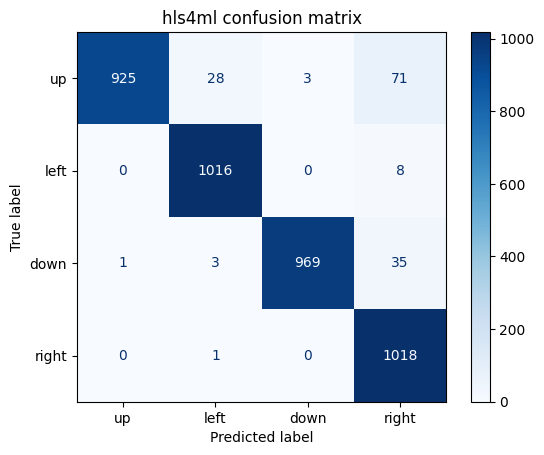

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

class_labels = ['up', 'left', 'down', 'right']

print(classification_report(y_true, hls_labels, target_names=class_labels))

cm = confusion_matrix(y_true, hls_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', values_format='d')
plt.title('hls4ml confusion matrix')
plt.show()

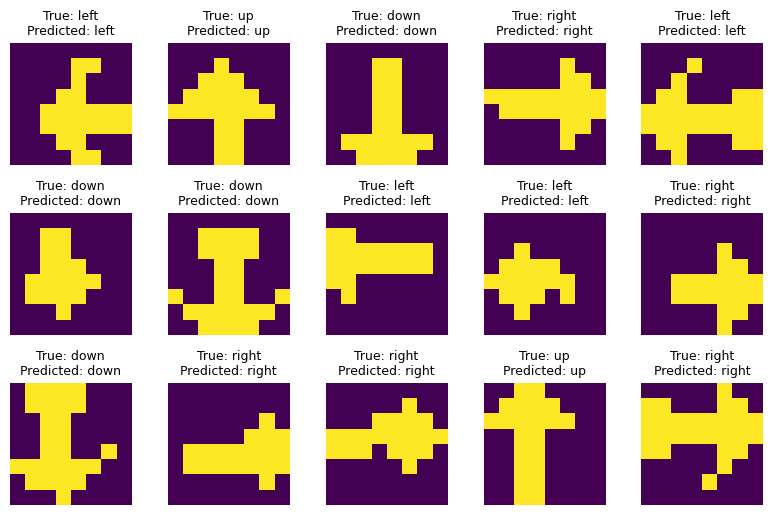

In [19]:
display_pred_grid(x_test, y_test, hls_labels)

### Optional HLS build

In [20]:
import os

os.environ["PATH"] += os.pathsep + '/tools/Xilinx/2025.1/Vitis/bin'
# Run this later when your Xilinx/Vivado or Vitis HLS toolchain is available.
# It can take a while and will create the HLS build outputs and reports.
hls_model.build(csim=False, synth=True, cosim=False, export=True)
hls4ml.report.read_vivado_report(str(hls_output_dir))


****** vitis-run v2025.1 (64-bit)
  **** SW Build 6137779 on 2025-05-21-18:10:03
  **** Start of session at: Sun May 17 14:53:59 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.1 6135595
Sourcing Tcl script '/home/szymon/projects/wedrowiec/hls4ml_projects/wedrowiec_hls/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project wedrowiec_hls_prj 
Resolution: For help on HLS 200-2182 see docs.xilinx.com/access/sources/dita/topic?Doc_Version=2025.1%20English&url=ug1448-hls-guidance&resourceid=200-2182.html
INFO: [HLS 200-10] Creating and opening solution '/home/szymon/projects/wedrowiec/hls4ml_projects/wedrowiec_hls/wedrowiec_hls_prj'.
INFO: [HLS 200-1510] Running: set_top wedrowiec_hls 
INFO: [HLS 200-1510] Running: add_files firmware/wedrowiec_hls.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/wedrowiec_hls.cpp' to the project
INFO: [HLS 200-151